<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW4/HW4_Seq2Seq_Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW3

#Imports

In [112]:
import torch
import torch.nn as nn
import torch.functional as F

import matplotlib.pyplot as plt
import numpy as np

import requests

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from torch import optim

torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
url = "https://raw.githubusercontent.com/JordanTerwilliger/Intro-to-Deep-Learning/refs/heads/main/HW3/vast_english_french.txt"
response = requests.get(url)
text = response.text  # This is the entire text data

#Preprocessing

In [113]:
def tokenize_and_pad(sentences, vocab):
    # Calculate the maximum sentence length for padding
    max_length = max(len(sentence.split(' ')) for sentence in sentences) + 2  # +2 for SOS and EOS tokens
    tokenized_sentences = []
    for sentence in sentences:
        # Convert each sentence to a list of indices, adding SOS and EOS tokens
        tokens = [vocab.word2index["<SOS>"]] + [vocab.word2index[word] for word in sentence.split(' ')] + [vocab.word2index["<EOS>"]]
        # Pad sentences to the maximum length
        padded_tokens = tokens + [vocab.word2index["<PAD>"]] * (max_length - len(tokens))
        tokenized_sentences.append(padded_tokens)
    return torch.tensor(tokenized_sentences, dtype=torch.long)

# Vocabulary class to handle mapping between words and numerical indices
class Vocabulary:
  def __init__(self):
    #Dictionaries for special tokens and reverse
    self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
    self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>"}
    self.word_count = {}  # Keep track of word frequencies
    self.n_words = 3  # Start counting from 3 to account for special tokens

  def add_sentence(self, sentence):
    # Add all words in a sentence to the vocabulary
    for word in sentence.split(' '):
      self.add_word(word)

  def add_word(self, word):
        # Add a word to the vocabulary
        if word not in self.word2index:
            # Assign a new index to the word and update mappings
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            # Increment word count if the word already exists in the vocabulary
            self.word_count[word] += 1

class EngFrDataset(Dataset):
    def __init__(self, pairs):
        self.eng_vocab = Vocabulary()
        self.fr_vocab = Vocabulary()
        self.pairs = []

        # Process each English-French pair
        for eng, fr in pairs:
            self.eng_vocab.add_sentence(eng)
            self.fr_vocab.add_sentence(fr)
            self.pairs.append((eng, fr))

        # Separate English and French sentences
        self.eng_sentences = [pair[0] for pair in self.pairs]
        self.fr_sentences = [pair[1] for pair in self.pairs]

        # Tokenize and pad sentences
        self.eng_tokens = tokenize_and_pad(self.eng_sentences, self.eng_vocab)
        self.fr_tokens = tokenize_and_pad(self.fr_sentences, self.fr_vocab)

    def __len__(self):
        # Return the number of sentence pairs
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get the tokenized and padded sentences by index
        eng_tokens = self.eng_tokens[idx]
        fr_tokens = self.fr_tokens[idx]
        return eng_tokens, fr_tokens

In [114]:
pairs = [
    tuple(part.strip() for part in line.split('\t')) for line in text.splitlines() if '\t' in line
]

dataset = EngFrDataset(pairs)

train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(1))

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
idx2w_e = dataset.eng_vocab.index2word
idx2w_f = dataset.fr_vocab.index2word
print(idx2w_e)
print(idx2w_f)
batch_size = 256
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)


{0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: 'I', 4: 'am', 5: 'cold', 6: 'You', 7: 'are', 8: 'tired', 9: 'He', 10: 'is', 11: 'hungry', 12: 'She', 13: 'happy', 14: 'We', 15: 'friends', 16: 'They', 17: 'students', 18: 'The', 19: 'cat', 20: 'sleeping', 21: 'sun', 22: 'shining', 23: 'love', 24: 'music', 25: 'speaks', 26: 'French', 27: 'fluently', 28: 'enjoys', 29: 'reading', 30: 'books', 31: 'play', 32: 'soccer', 33: 'every', 34: 'weekend', 35: 'movie', 36: 'starts', 37: 'at', 38: '7', 39: 'PM', 40: 'wears', 41: 'a', 42: 'red', 43: 'dress', 44: 'cook', 45: 'dinner', 46: 'together', 47: 'drives', 48: 'blue', 49: 'car', 50: 'visit', 51: 'museums', 52: 'often', 53: 'restaurant', 54: 'serves', 55: 'delicious', 56: 'food', 57: 'studies', 58: 'mathematics', 59: 'university', 60: 'watch', 61: 'movies', 62: 'on', 63: 'Fridays', 64: 'listens', 65: 'to', 66: 'while', 67: 'jogging', 68: 'travel', 69: 'around', 70: 'the', 71: 'world', 72: 'book', 73: 'table', 74: 'dances', 75: 'gracefully', 76: 'celebrate'

#Model Creation

In [115]:
#d_model = hidden_size
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0).to(device)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)].detach()

#Create Model
class TransformerModel(nn.Module):
  def __init__(self, input_size, output_size, hidden_size, nhead, num_layers):
    super(TransformerModel, self).__init__()

    self.source_embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)
    self.target_embedding = nn.Embedding(output_size, hidden_size, padding_idx=0) #PAD = 0

    self.pos_encoder = PositionalEncoding(hidden_size)

    encoder_layers = nn.TransformerEncoderLayer(hidden_size, nhead, batch_first = True)
    self.encoder = nn.TransformerEncoder(encoder_layers, num_layers)

    decoder_layers = nn.TransformerDecoderLayer(hidden_size, nhead, batch_first=True)
    self.decoder = nn.TransformerDecoder(decoder_layers, num_layers)

    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, source, target):
    source_embedded = self.pos_encoder(self.source_embedding(source))
    target_embedded = self.pos_encoder(self.target_embedding(target))

    encoder_output = self.encoder(source_embedded)

    tgt_len = target.size(1)
    causal_mask = torch.triu(
        torch.full((tgt_len, tgt_len), float('-inf'), device=target.device),
        diagonal=1
    )

    decoder_output = self.decoder(target_embedded, encoder_output, tgt_mask=causal_mask)
    return self.fc(decoder_output)

  @torch.no_grad()
  def greedy_decode(self, source, max_len, sos_idx=1, eos_idx=2):
    self.eval()
    source_embedded = self.pos_encoder(self.source_embedding(source))
    encoder_output = self.encoder(source_embedded)

    batch_size = source.size(0)
    ys = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=source.device)

    for _ in range(max_len - 1):
        target_embedded = self.pos_encoder(self.target_embedding(ys))
        tgt_len = ys.size(1)
        causal_mask = torch.triu(
            torch.full((tgt_len, tgt_len), float('-inf'), device=source.device),
            diagonal=1
        )
        decoder_output = self.decoder(target_embedded, encoder_output, tgt_mask=causal_mask)
        next_token_logits = self.fc(decoder_output[:, -1, :])
        next_token = next_token_logits.argmax(-1, keepdim=True)
        ys = torch.cat([ys, next_token], dim=1)
        if (next_token == eos_idx).all():
            break
    return ys

In [116]:
learning_rate = 0.001
input_size = len(dataset.eng_vocab.index2word)
hidden_size = 256
output_size = len(dataset.fr_vocab.index2word)
nhead = 2
num_layers = 1
epochs = 100

model = TransformerModel(input_size, output_size, hidden_size, nhead, num_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # ignore padding (index 0)


In [117]:
def createPlot(train_loss_list, val_loss_list, val_accuracy_list):
  import matplotlib.pyplot as plt
  plt.figure(figsize=(10, 6))
  plt.plot(train_loss_list, label='Training Loss')
  plt.plot(val_loss_list, label='Validation Loss')
  plt.title('Training and Validation Loss Over Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

#Training Loop


Epoch 0, Loss: 2.1766, Val Accuracy: 0.1197, Val Loss: 3.7582
Epoch 1, Loss: 0.9178, Val Accuracy: 0.1197, Val Loss: 3.4912
Epoch 2, Loss: 0.5881, Val Accuracy: 0.1197, Val Loss: 3.0919
Epoch 3, Loss: 0.3850, Val Accuracy: 0.1478, Val Loss: 2.9063
Epoch 4, Loss: 0.3049, Val Accuracy: 0.1424, Val Loss: 2.7739
Epoch 5, Loss: 0.2319, Val Accuracy: 0.1381, Val Loss: 2.6729
Epoch 6, Loss: 0.1925, Val Accuracy: 0.1348, Val Loss: 2.6228
Epoch 7, Loss: 0.1632, Val Accuracy: 0.1413, Val Loss: 2.5486
Epoch 8, Loss: 0.1412, Val Accuracy: 0.1704, Val Loss: 2.4974
Epoch 9, Loss: 0.1221, Val Accuracy: 0.1791, Val Loss: 2.4490
Epoch 10, Loss: 0.1054, Val Accuracy: 0.1435, Val Loss: 2.4098
Epoch 11, Loss: 0.0923, Val Accuracy: 0.1791, Val Loss: 2.3670
Epoch 12, Loss: 0.0823, Val Accuracy: 0.1791, Val Loss: 2.3362
Epoch 13, Loss: 0.0742, Val Accuracy: 0.1704, Val Loss: 2.3038
Epoch 14, Loss: 0.0675, Val Accuracy: 0.1748, Val Loss: 2.2767
Epoch 15, Loss: 0.0603, Val Accuracy: 0.1704, Val Loss: 2.2530
Ep

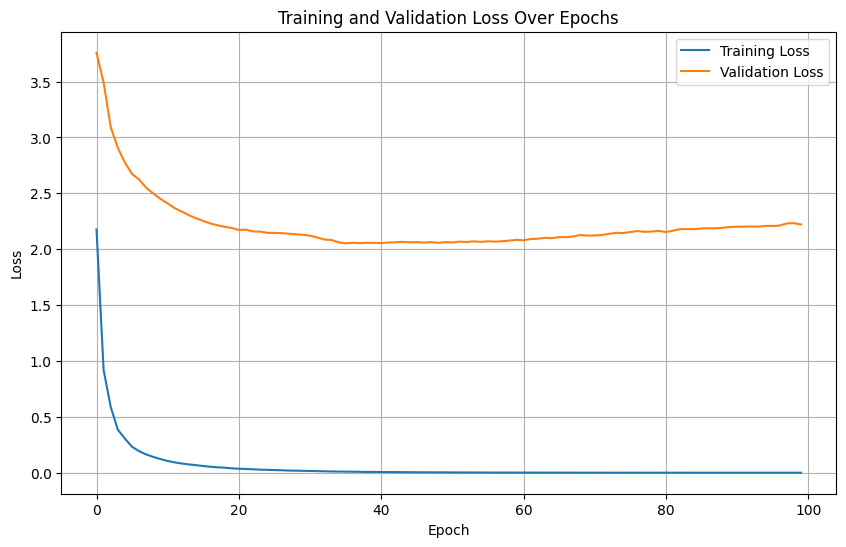

In [118]:
# Training Loop
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
train_batches = 0

#Create a new training loop for each input_length
for epoch in range(epochs):
  model.train()
  for X_train, y_train in train_loader:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    epoch_train_loss = 0.0

    optimizer.zero_grad()

    tgt_input = y_train[:, :-1]   # drop last token (usually EOS/PAD)
    tgt_output = y_train[:, 1:]   # drop first token (SOS)
    y_pred = model(X_train, tgt_input)
    loss = criterion(y_pred.reshape(-1, y_pred.size(-1)), tgt_output.reshape(-1))

    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1


# Validation Loop
  model.eval()

  total_val_loss = 0.0
  total_val_acc = 0.0
  val_batches = 0

  with torch.no_grad():
    for X_test, y_test in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      # Teacher-forced loss (for comparable loss curve — model still sees ground truth here)
      tgt_input_val = y_test[:, :-1]
      tgt_output_val = y_test[:, 1:]
      val_output = model(X_test, tgt_input_val)
      val_loss = criterion(val_output.reshape(-1, val_output.size(-1)), tgt_output_val.reshape(-1))

      generated = model.greedy_decode(X_test, max_len=y_test.size(1))
      # Pad/truncate generated to match y_test length for elementwise comparison
      gen_len = generated.size(1)
      tgt_len = y_test.size(1)
      if gen_len < tgt_len:
        pad = torch.full((generated.size(0), tgt_len - gen_len), PAD_IDX, device=device, dtype=torch.long)
        generated = torch.cat([generated, pad], dim=1)
      else:
        generated = generated[:, :tgt_len]

      mask = (y_test != PAD_IDX)
      correct = ((generated == y_test) & mask).sum().item()
      total = mask.sum().item()
      val_accuracy = correct / total if total > 0 else 0.0

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy
      val_batches += 1

  avg_train_loss = epoch_train_loss / train_batches
  avg_val_loss = total_val_loss / val_batches
  avg_val_acc = total_val_acc / val_batches

  train_loss_list.append(avg_train_loss)
  val_loss_list.append(avg_val_loss)
  val_accuracy_list.append(avg_val_acc)

  if (epoch % 10 == 0):
    print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
createPlot(train_loss_list, val_loss_list, val_accuracy_list)



In [121]:
def tokens_to_words(tokens, idx2word):
    words = []
    for t in tokens:
        t = t.item() if torch.is_tensor(t) else t
        if t == EOS_IDX:
            break
        if t in (PAD_IDX, SOS_IDX):
            continue
        words.append(idx2word[t])
    return words

smoothie = SmoothingFunction().method4

def evaluate_epoch(model, loader, fr_idx2word):
    model.eval()
    total_loss, batches = 0.0, 0
    exact_matches, total_seqs = 0, 0
    bleu_scores = []
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            tgt_in, tgt_out = y[:, :-1], y[:, 1:]
            logits = model(X, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            total_loss += loss.item()
            batches += 1

            preds = model.greedy_translate(X, max_len=y.size(1))
            for i in range(X.size(0)):
                pred_words = tokens_to_words(preds[i, 1:], fr_idx2word)
                ref_words = tokens_to_words(y[i, 1:], fr_idx2word)
                total_seqs += 1
                if pred_words == ref_words:
                    exact_matches += 1
                if len(ref_words) > 0:
                    bleu_scores.append(sentence_bleu([ref_words], pred_words, smoothing_function=smoothie))

    return (total_loss / batches,
            exact_matches / total_seqs,
            sum(bleu_scores) / len(bleu_scores))